# Logistic regression

Logistic regression models the probability of a binary outcome $Y \in \{0, 1\}$ as

$$P(Y = 1 \mid x) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 x_1 + \dots + \beta_p x_p)}}, \qquad
\log \frac{P(Y=1 \mid x)}{P(Y=0 \mid x)} = \beta_0 + \beta_1 x_1 + \dots + \beta_p x_p ,$$

so each coefficient is the change in the **log-odds** of the outcome for a unit change in the predictor, and $e^{\beta_j}$ is an **odds ratio**.

The notebook covers two problems:

1. **Credit card default**: interpreting coefficients, a confounding effect that reverses the sign of a predictor, and what goes wrong when one class is rare.
2. **Fuel efficiency of cars**: building a classifier, estimating its error honestly, and choosing the decision threshold with the ROC curve.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (ConfusionMatrixDisplay, accuracy_score, confusion_matrix, f1_score,
                             precision_score, recall_score, roc_auc_score, roc_curve)
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

plt.rcParams["figure.dpi"] = 100

## 1. Credit card default

The dataset contains 10,000 credit card customers: whether they defaulted on their debt, whether they are students, their monthly credit card balance and their annual income.

In [2]:
credit = pd.read_csv("data/default.csv")
credit["defaulted"] = (credit["default"] == "Yes").astype(int)
credit["student"] = (credit["student"] == "Yes").astype(int)
credit["income_k"] = credit["income"] / 1000

print(f"default rate: {credit['defaulted'].mean():.1%}  ({credit['defaulted'].sum()} of {len(credit)})")
credit.groupby("defaulted")[["balance", "income_k", "student"]].mean().round(2)

default rate: 3.3%  (333 of 10000)


,balance,income_k,student
defaulted,,,
0,803.94,33.57,0.29
1,1747.82,32.09,0.38


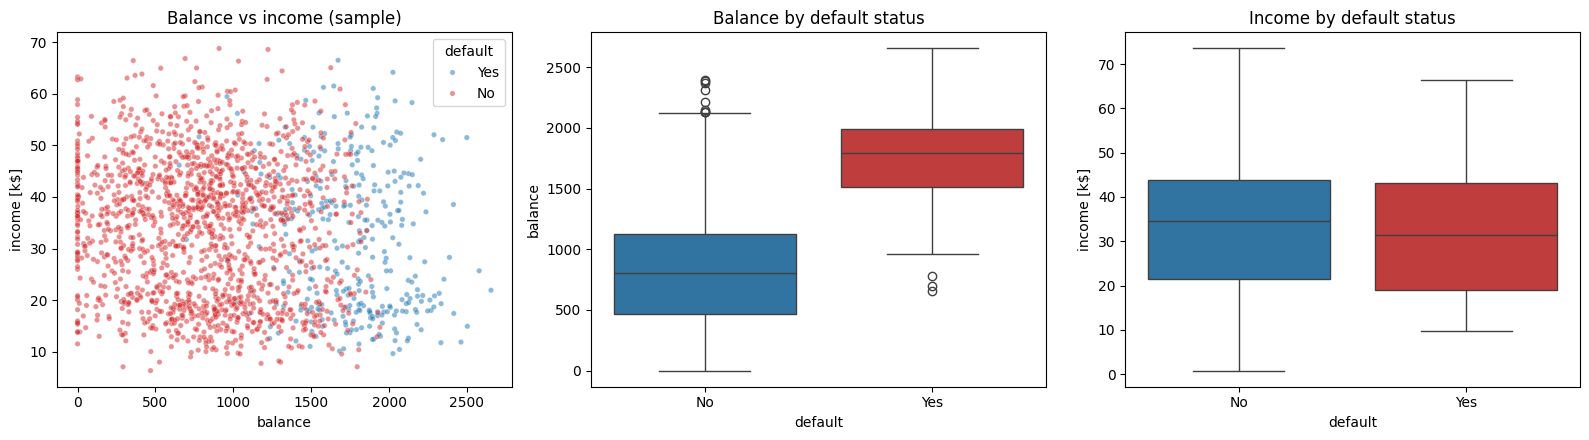

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
sample = pd.concat([credit[credit["defaulted"] == 1], credit[credit["defaulted"] == 0].sample(1500, random_state=0)])
sns.scatterplot(data=sample, x="balance", y="income_k", hue="default", alpha=0.5, s=15, ax=axes[0], palette=["tab:blue", "tab:red"])
axes[0].set(title="Balance vs income (sample)", ylabel="income [k$]")
sns.boxplot(data=credit, x="default", y="balance", ax=axes[1], hue="default", palette=["tab:blue", "tab:red"], legend=False)
axes[1].set_title("Balance by default status")
sns.boxplot(data=credit, x="default", y="income_k", ax=axes[2], hue="default", palette=["tab:blue", "tab:red"], legend=False)
axes[2].set(title="Income by default status", ylabel="income [k$]")
fig.tight_layout()
plt.show()

Only 3.3% of customers default. Those who do carry a much higher balance, while income barely differs between the two groups.

### Students: riskier or safer?

A model with student status as the only predictor:

In [4]:
student_only = smf.logit("defaulted ~ student", data=credit).fit(disp=0)
print(student_only.summary().tables[1])
p = student_only.predict(pd.DataFrame({"student": [0, 1]}))
print(f"\nP(default | non-student) = {p[0]:.2%}\nP(default | student)     = {p[1]:.2%}")

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -3.5041      0.071    -49.554      0.000      -3.643      -3.366
student        0.4049      0.115      3.520      0.000       0.179       0.630

P(default | non-student) = 2.92%
P(default | student)     = 4.31%


Students default more often (4.3% vs 2.9%): the coefficient is positive and significant. Now we add balance and income:

In [5]:
full = smf.logit("defaulted ~ balance + income_k + student", data=credit).fit(disp=0)
print(full.summary().tables[1])

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -10.8690      0.492    -22.079      0.000     -11.834      -9.904
balance        0.0057      0.000     24.737      0.000       0.005       0.006
income_k       0.0030      0.008      0.370      0.712      -0.013       0.019
student       -0.6468      0.236     -2.738      0.006      -1.110      -0.184


Income is not significant once balance is known, but the striking result is that **the student coefficient is now negative**: for the same balance and income, a student is *less* likely to default than a non-student. Both results are correct; they answer different questions.

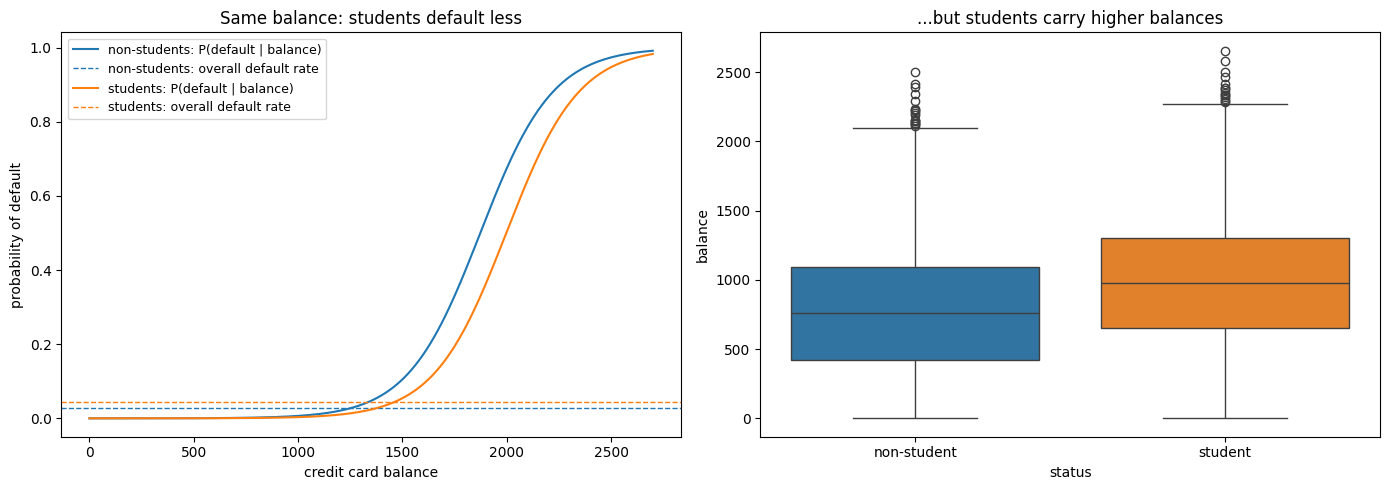

In [6]:
model = smf.logit("defaulted ~ balance + student", data=credit).fit(disp=0)
grid = np.linspace(0, 2700, 300)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
for s, color, label in [(0, "tab:blue", "non-students"), (1, "tab:orange", "students")]:
    curve = model.predict(pd.DataFrame({"balance": grid, "student": s}))
    ax1.plot(grid, curve, color=color, label=f"{label}: P(default | balance)")
    overall = credit.loc[credit["student"] == s, "defaulted"].mean()
    ax1.axhline(overall, color=color, ls="--", lw=1, label=f"{label}: overall default rate")
ax1.set(xlabel="credit card balance", ylabel="probability of default", title="Same balance: students default less")
ax1.legend(fontsize=9)
sns.boxplot(data=credit.assign(status=credit["student"].map({0: "non-student", 1: "student"})),
            x="status", y="balance", ax=ax2, hue="status", palette=["tab:blue", "tab:orange"], legend=False)
ax2.set_title("...but students carry higher balances")
fig.tight_layout()
plt.show()

The two plots explain the paradox. **Students carry higher balances on average** (about 990 vs 770), and balance is the main driver of default. Taken as a group, students therefore default more often. Compared at the *same* balance, though, a student is a safer customer.

Balance is a **confounder** of the relationship between student status and default. A bank that ignores it would wrongly conclude that students are riskier as individuals. This is why multiple models matter: the coefficient of a predictor depends on which other predictors are in the model.

### Accuracy is misleading when classes are rare

We now use the model as a classifier: predict default when the estimated probability exceeds 0.5.

In [7]:
def classification_report(y_true, prob, threshold=0.5):
    pred = (prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred).ravel()
    return pd.Series({
        "accuracy": (tp + tn) / len(y_true),
        "recall (defaults caught)": tp / (tp + fn),
        "precision": tp / (tp + fp),
        "false alarms": fp,
        "missed defaults": fn,
    })

prob = model.predict(credit)
print(f"Accuracy of always predicting 'no default': {1 - credit['defaulted'].mean():.1%}")
classification_report(credit["defaulted"], prob).round(3)

Accuracy of always predicting 'no default': 96.7%


accuracy                      0.973
recall (defaults caught)      0.315
precision                     0.729
false alarms                 39.000
missed defaults             228.000
dtype: float64

An accuracy of 97.3% sounds excellent, but a trivial rule that never predicts default already reaches 96.7%. More importantly, the model catches only **31%** of the customers who actually default: it misses 228 of 333.

With rare positives, the 0.5 threshold is a poor choice: the model rarely becomes confident enough to predict the minority class. Lowering the threshold trades false alarms for caught defaults:

In [8]:
pd.DataFrame({t: classification_report(credit["defaulted"], prob, t) for t in (0.5, 0.3, 0.2, 0.1)}).round(3)

,0.5,0.3,0.2,0.1
accuracy,0.973,0.970,0.959,0.935
recall (defaults caught),0.315,0.508,0.610,0.742
precision,0.729,0.558,0.424,0.306
false alarms,39.000,134.000,276.000,561.000
missed defaults,228.000,164.000,130.000,86.000


At a threshold of 0.1 the model catches three quarters of the defaults, at the price of more false alarms and slightly lower accuracy. Which threshold is best depends on the **costs**: if a missed default costs the bank far more than an extra credit check, a low threshold is the right choice even though "accuracy" drops.

**Takeaway:** for imbalanced problems, report recall and precision (or the full confusion matrix) rather than accuracy, and choose the threshold according to the cost of each type of error.

## 2. Fuel efficiency: building and evaluating a classifier

The Auto dataset describes 392 cars from the 1970s and early 1980s. We define a binary target, `high_mpg`, equal to 1 if a car's fuel efficiency is above the median. Since the threshold is the median, the two classes are perfectly balanced.

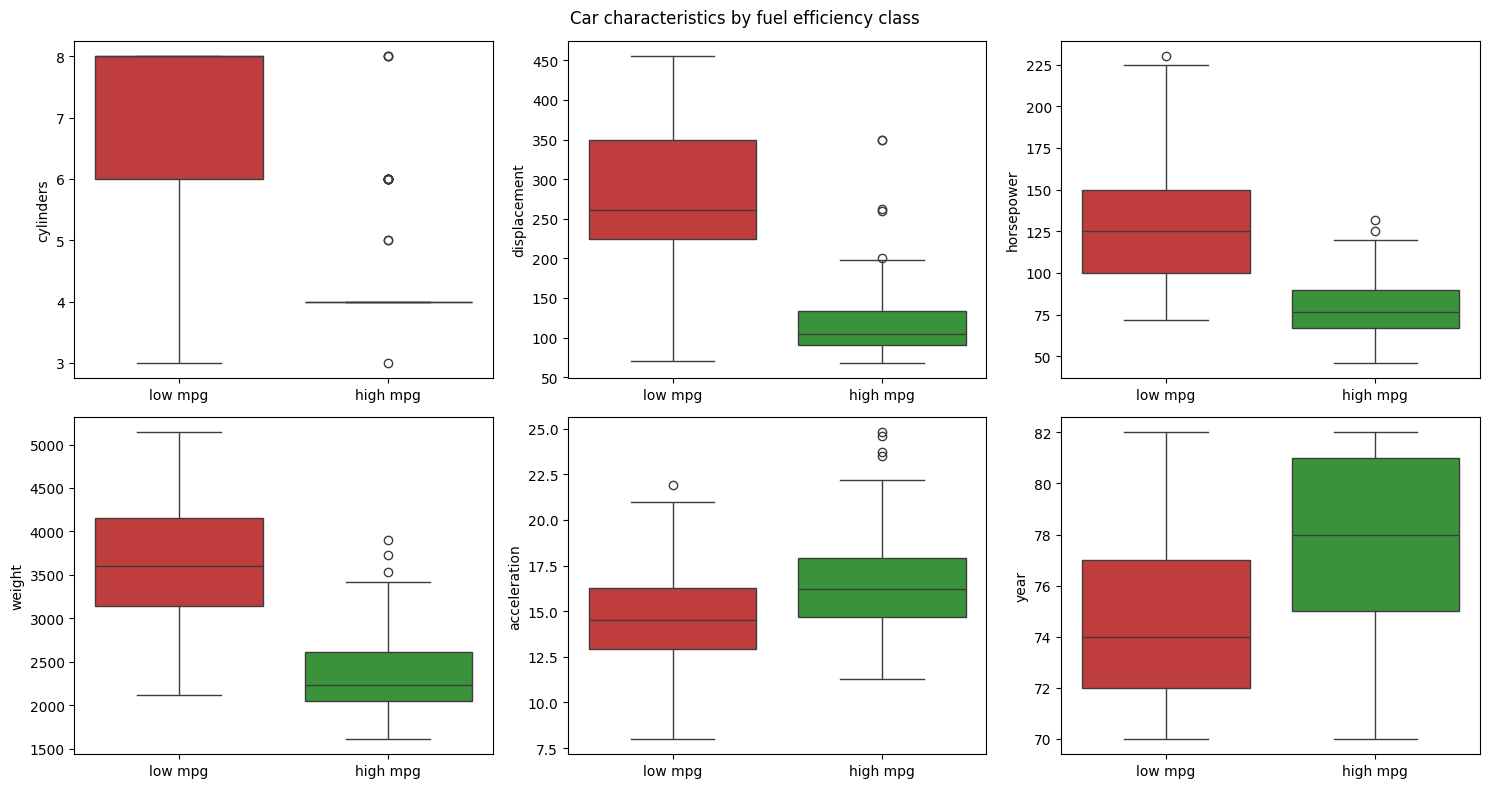

In [9]:
auto = pd.read_csv("data/auto.csv")
auto["high_mpg"] = (auto["mpg"] > auto["mpg"].median()).astype(int)
auto["origin"] = auto["origin"].map({1: "America", 2: "Europe", 3: "Japan"})
numeric = ["cylinders", "displacement", "horsepower", "weight", "acceleration", "year"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, numeric):
    sns.boxplot(data=auto, x="high_mpg", y=col, ax=ax, hue="high_mpg", palette=["tab:red", "tab:green"], legend=False)
    ax.set_xticks([0, 1], ["low mpg", "high mpg"])
    ax.set_xlabel("")
fig.suptitle("Car characteristics by fuel efficiency class")
fig.tight_layout()
plt.show()

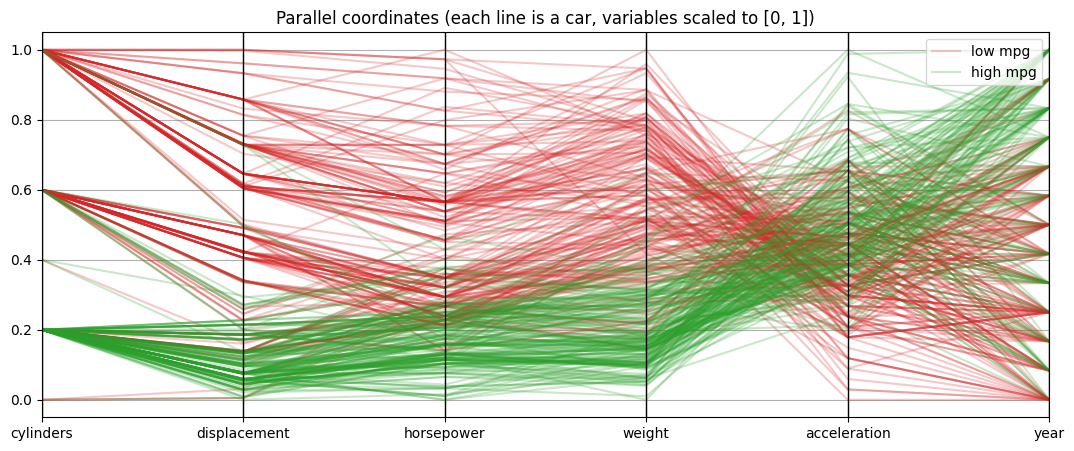

high_mpg,high mpg,low mpg,All
origin,,,
America,72,173,245
Europe,54,14,68
Japan,70,9,79
All,196,196,392


In [10]:
from pandas.plotting import parallel_coordinates

scaled = auto[numeric].apply(lambda c: (c - c.min()) / (c.max() - c.min()))
fig, ax = plt.subplots(figsize=(13, 5))
parallel_coordinates(scaled.assign(high_mpg=auto["high_mpg"].map({0: "low mpg", 1: "high mpg"})),
                     "high_mpg", color=["tab:red", "tab:green"], alpha=0.25, ax=ax)
ax.set(title="Parallel coordinates (each line is a car, variables scaled to [0, 1])")
plt.show()

pd.crosstab(auto["origin"], auto["high_mpg"].map({0: "low mpg", 1: "high mpg"}), margins=True)

The classes separate clearly: efficient cars are lighter, have smaller engines with fewer cylinders and less horsepower, and are more recent. In the parallel coordinate plot the red and green lines run through different ranges of almost every variable. Origin also matters: most American cars are in the low class, while most European and Japanese cars are in the high class.

### Training, test and cross-validation error

We hold out 20% of the cars as a test set, stratified so that both sets keep the 50/50 class balance.

In [11]:
X = pd.get_dummies(auto[numeric + ["origin"]], columns=["origin"], drop_first=True, dtype=float)
y = auto["high_mpg"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2, stratify=y)

logit = make_pipeline(StandardScaler(), LogisticRegression(penalty=None, max_iter=1000)).fit(X_train, y_train)
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=0)

errors = pd.Series({
    "training error": 1 - logit.score(X_train, y_train),
    "10-fold CV error (training set)": 1 - cross_val_score(logit, X_train, y_train, cv=cv).mean(),
    "test error": 1 - logit.score(X_test, y_test),
})
errors.round(3)

training error                     0.093
10-fold CV error (training set)    0.099
test error                         0.101
dtype: float64

The training error (9%) is optimistic, because the model is evaluated on the same cars it was fitted on. The cross-validated error and the test error (both about 10%) agree and are the honest estimate: the model misclassifies about one car in ten. Cross-validation has the advantage of not sacrificing any data, and of averaging over ten different splits instead of one.

Which characteristics drive the prediction? With standardized predictors, the coefficients are comparable:

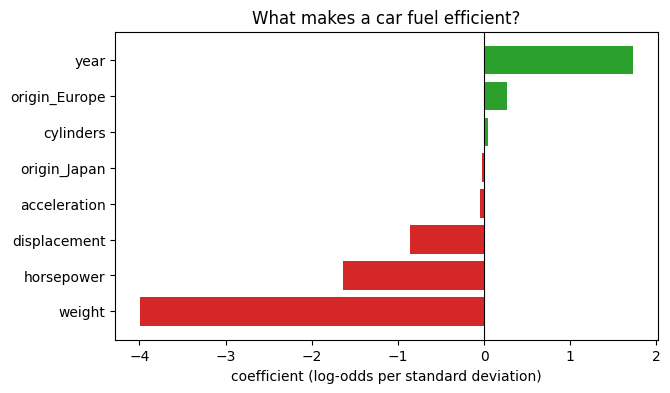

In [12]:
coefs = pd.Series(logit[-1].coef_[0], index=X.columns).sort_values()
fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(coefs.index, coefs.values, color=np.where(coefs > 0, "tab:green", "tab:red"))
ax.axvline(0, color="black", lw=0.8)
ax.set(xlabel="coefficient (log-odds per standard deviation)", title="What makes a car fuel efficient?")
plt.show()

**Weight** dominates: every standard deviation of extra weight strongly lowers the odds of being efficient. **Model year** is the second strongest effect: newer cars are much more likely to be efficient, as fuel economy improved quickly after the oil crises of the 1970s. Horsepower and displacement also push towards low efficiency, but the engine variables are strongly correlated with weight and with each other, so their individual coefficients should not be over-interpreted (see the multicollinearity notebook in the regression folder).

Origin, which looked so important in the contingency table, has almost no effect once the other variables are in the model. It is the same confounding seen with the students: European and Japanese cars are efficient mostly because they are **lighter**, not because of where they were built.

### Confusion matrix and metrics on the test set

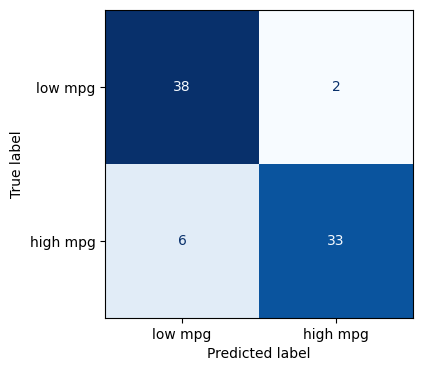

accuracy     0.899
precision    0.943
recall       0.846
F1 score     0.892
dtype: float64

In [13]:
prob_test = logit.predict_proba(X_test)[:, 1]
pred_test = (prob_test >= 0.5).astype(int)

fig, ax = plt.subplots(figsize=(4.5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, pred_test, display_labels=["low mpg", "high mpg"], cmap="Blues", ax=ax, colorbar=False)
plt.show()

pd.Series({
    "accuracy": accuracy_score(y_test, pred_test),
    "precision": precision_score(y_test, pred_test),
    "recall": recall_score(y_test, pred_test),
    "F1 score": f1_score(y_test, pred_test),
}).round(3)

Taking "high mpg" as the positive class:

- **precision** = TP / (TP + FP): of the cars predicted as efficient, 94% really are;
- **recall** = TP / (TP + FN): of the truly efficient cars, the model finds 85%;
- **F1** is the harmonic mean of the two.

### ROC curve and the choice of threshold

Every threshold $t$ gives a different classifier, with its own **true positive rate** (recall) and **false positive rate** (share of negatives wrongly flagged). The ROC curve traces all these classifiers at once. To make the mechanics explicit, we compute it by hand by sweeping the threshold from 1 down to 0:

In [14]:
def roc_points(y_true, prob, thresholds):
    y_true = np.asarray(y_true)
    rows = []
    for t in thresholds:
        pred = prob >= t
        tpr = (pred & (y_true == 1)).sum() / (y_true == 1).sum()
        fpr = (pred & (y_true == 0)).sum() / (y_true == 0).sum()
        rows.append((t, fpr, tpr))
    return pd.DataFrame(rows, columns=["threshold", "fpr", "tpr"])

prob_train = logit.predict_proba(X_train)[:, 1]
# Every distinct predicted probability is a threshold where the classification changes
thresholds = np.r_[1.01, np.unique(np.r_[prob_train, prob_test])[::-1], 0]
roc_train = roc_points(y_train, prob_train, thresholds)
roc_test = roc_points(y_test, prob_test, thresholds)

# Area under the curve with the trapezoidal rule
auc = {name: np.trapz(r["tpr"], r["fpr"]) for name, r in [("train", roc_train), ("test", roc_test)]}
print({k: round(v, 3) for k, v in auc.items()}, "| scikit-learn test AUC:", round(roc_auc_score(y_test, prob_test), 3))

{'train': 0.98, 'test': 0.957} | scikit-learn test AUC: 0.957


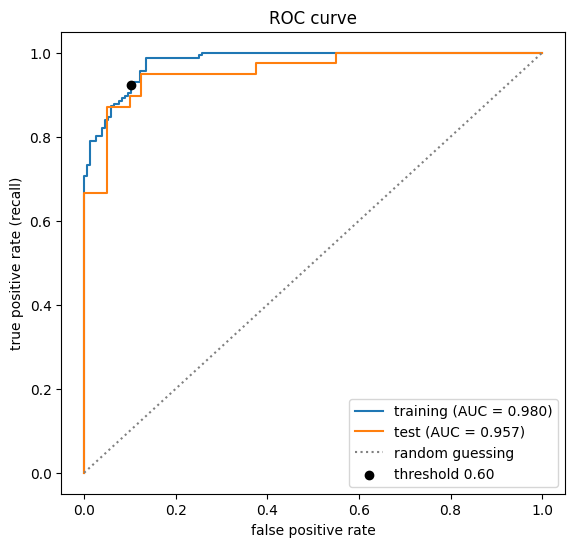

In [15]:
# Threshold closest to the ideal corner (FPR = 0, TPR = 1), chosen on the training data
dist = np.hypot(roc_train["fpr"], 1 - roc_train["tpr"])
best = roc_train.loc[dist.idxmin()]

fig, ax = plt.subplots(figsize=(6.5, 6))
ax.plot(roc_train["fpr"], roc_train["tpr"], label=f"training (AUC = {auc['train']:.3f})")
ax.plot(roc_test["fpr"], roc_test["tpr"], label=f"test (AUC = {auc['test']:.3f})")
ax.plot([0, 1], [0, 1], ":", color="grey", label="random guessing")
ax.scatter(best["fpr"], best["tpr"], color="black", zorder=3, label=f"threshold {best['threshold']:.2f}")
ax.set(xlabel="false positive rate", ylabel="true positive rate (recall)", title="ROC curve")
ax.legend(loc="lower right")
plt.show()

- A perfect classifier passes through the top-left corner; random guessing follows the diagonal.
- The **area under the curve** (AUC) summarizes the whole curve in one number: the probability that a randomly chosen efficient car gets a higher score than a randomly chosen inefficient one. Here it is about 0.96 on the test set, so the model ranks cars very well.
- A simple rule for the threshold is to take the point closest to the top-left corner. It should be chosen on the **training** data (or by cross-validation) to avoid tuning on the test set. When the costs of the two errors differ, as in the credit example, the threshold should reflect those costs instead.

## Summary

- Logistic regression coefficients are changes in **log-odds**; like in linear regression, they depend on which other predictors are in the model, and a **confounder** can even reverse their sign.
- **Accuracy** is misleading for imbalanced classes. Use recall, precision and the confusion matrix, and choose the threshold according to the cost of errors.
- The **training error** is optimistic; cross-validation and a held-out test set give honest estimates, and should agree.
- The **ROC curve** and the AUC evaluate a classifier over all thresholds at once and help choose the operating point.